# Drug Side-Effect Prediction — Decagon Polypharmacy Dataset

**Dataset:** This project uses the **Decagon polypharmacy side-effect dataset** (Zitnik et al.), a real,
published drug-drug interaction dataset — not a synthetic or toy dataset. It contains 645 real drugs,
63,473 real interacting drug pairs, and 1,317 distinct recorded side effects.

**Goal:** Given a pair of drugs, predict which side effects that combination is likely to cause, using
both classical machine learning (Scikit-learn, TensorFlow) and a Graph Neural Network (PyTorch Geometric)
that exploits the real drug-drug interaction network — then compare the two approaches directly.

**Pipeline overview:**
1. Load and subsample the real interaction data
2. Retrieve each drug's chemical structure (SMILES) from PubChem and convert it to a numeric fingerprint (RDKit)
3. Explore the data (EDA) and store it in a SQL database
4. Cluster drugs by side-effect profile (unsupervised ML)
5. Predict a "side-effect burden" score for each drug (regression)
6. Predict side effects for a drug pair (classification: Random Forest + TensorFlow)
7. Predict side effects for a drug pair using a Graph Neural Network that leverages the real interaction
   network, and benchmark it against the flat-feature classification baseline — this is the project's key
   comparison
8. Consolidate all metrics and export results for reporting (Excel / Power BI)


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/ChChSe-Decagon_polypharmacy[1].csv")
df.columns = ['drug_1', 'drug_2', 'side_effect_code', 'side_effect_name']
df.head()

,drug_1,drug_2,side_effect_code,side_effect_name
0,CID000002173,CID000003345,C0151714,hypermagnesemia
1,CID000002173,CID000003345,C0035344,retinopathy of prematurity
2,CID000002173,CID000003345,C0004144,atelectasis
3,CID000002173,CID000003345,C0002063,alkalosis
4,CID000002173,CID000003345,C0004604,Back Ache


In [101]:
print(df.shape)
print("Unique drugs:", pd.concat([df['drug_1'], df['drug_2']]).nunique())
print("Unique side effects:", df['side_effect_name'].nunique())
print("Unique drug pairs:", df[['drug_1','drug_2']].drop_duplicates().shape[0])

(4649441, 4)
Unique drugs: 645
Unique side effects: 1317
Unique drug pairs: 63473


Subsample for tractability

## Step 1: Subsample the data for tractability

The full dataset (4.6M rows, 645 drugs, 1,317 side effects) is too large to train comfortably in a
notebook environment, so a manageable subset is taken and used for every step below.

**Sampling method — an important methodological choice:** drugs are sampled from those with
**moderate** connectivity (`50 < degree < 5000`), not simply the most-connected drugs. An earlier version
of this pipeline picked the top-150 most-connected drugs directly, which produced a near-complete
drug-interaction graph (over 99% density). A graph that dense causes a Graph Neural Network to
"oversmooth" — every drug's learned representation ends up nearly identical to every other drug's,
because two rounds of message-passing average over almost the entire drug set. Sampling drugs with
moderate (rather than maximal) connectivity instead produces a genuinely sparse graph (~3% density in
the final run), which is what a GNN actually needs in order to learn meaningful structure. This is
explicitly reported here rather than hidden, since it materially affects the validity of the later GNN
comparison.

In [102]:
np.random.seed(42)
all_drugs = pd.concat([df['drug_1'], df['drug_2']])
degree_counts = all_drugs.value_counts()

# Pick drugs with moderate connectivity, not the most-connected ones
moderate_drugs = degree_counts[(degree_counts > 50) & (degree_counts < 5000)].index
top_drugs = np.random.choice(moderate_drugs, size=min(150, len(moderate_drugs)), replace=False).tolist()

df_sub = df[df['drug_1'].isin(top_drugs) & df['drug_2'].isin(top_drugs)]

top_effects = df_sub['side_effect_name'].value_counts().head(50).index.tolist()
df_sub = df_sub[df_sub['side_effect_name'].isin(top_effects)]

print(f"Drugs: {len(top_drugs)}, Pairs: {df_sub[['drug_1','drug_2']].drop_duplicates().shape[0]}")
print(df_sub.shape)
print("Drugs remaining:", pd.concat([df_sub['drug_1'], df_sub['drug_2']]).nunique())
print("Pairs remaining:", df_sub[['drug_1','drug_2']].drop_duplicates().shape[0])

Drugs: 150, Pairs: 166
(1093, 4)
Drugs remaining: 98
Pairs remaining: 166


## Step 2: Clean drug IDs

The drug identifiers in this dataset are STITCH-formatted PubChem Compound IDs (e.g. `CID000002173`).
Stripping the `"CID"` prefix and leading zeros recovers the real PubChem CID (`2173`), which can be used
to query PubChem directly for the chemical structure of each drug.

In [103]:
def clean_cid(stitch_id):
    return int(stitch_id.replace("CID", "").lstrip("0") or "0")

df_sub['cid_1'] = df_sub['drug_1'].apply(clean_cid)
df_sub['cid_2'] = df_sub['drug_2'].apply(clean_cid)

unique_cids = pd.concat([df_sub['cid_1'], df_sub['cid_2']]).unique()
print(f"Need SMILES for {len(unique_cids)} unique compounds")

Need SMILES for 98 unique compounds


## Step 3: Retrieve chemical structure (SMILES) and compute fingerprints

**PubChem** is a free public chemistry database (run by the NIH/NCBI) that stores structural and property
data for over 100 million compounds. Each drug's cleaned PubChem CID is used to query PubChem for its
**SMILES** string — a compact text representation of the molecule's atoms and bonds.

**RDKit** is then used to parse each SMILES string into an actual molecule object and compute a
**Morgan fingerprint**: a fixed-length (512-bit) numeric vector encoding which small structural
sub-patterns are present in the molecule. This fingerprint is the numeric representation of each drug's
chemistry that all downstream models (clustering, regression, classification, and the GNN) are trained
on — chemical structure is the only real signal available in this dataset, since no severity, dosage,
or patient-level information is provided.

In [104]:
!pip install pubchempy

In [105]:
import pubchempy as pcp
import time

smiles_map = {}
for cid in unique_cids:
    try:
        compound = pcp.Compound.from_cid(int(cid))
        smiles_map[cid] = compound.isomeric_smiles
    except Exception:
        smiles_map[cid] = None
    time.sleep(0.2)

found = sum(1 for v in smiles_map.values() if v is not None)
print(f"Found SMILES for {found} / {len(unique_cids)} compounds")

/tmp/ipykernel_436/3285732735.py:8: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  smiles_map[cid] = compound.isomeric_smiles


Found SMILES for 98 / 98 compounds


In [106]:
!pip install rdkit

In [107]:
from rdkit import Chem
from rdkit.Chem import AllChem

fingerprints = {}
for cid, smiles in smiles_map.items():
    if smiles is not None:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=512)
            fingerprints[cid] = np.array(fp)

valid_cids = list(fingerprints.keys())
print(f"Usable fingerprints: {len(valid_cids)}")

# Keep only pairs where BOTH drugs have a usable fingerprint
df_sub = df_sub[df_sub['cid_1'].isin(valid_cids) & df_sub['cid_2'].isin(valid_cids)]
print(f"Remaining pairs after filtering: {df_sub[['cid_1','cid_2']].drop_duplicates().shape[0]}")

Usable fingerprints: 98
Remaining pairs after filtering: 166


[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerator
[16:39:28] DEPRECATION WARNING: please use MorganGenerat

Explore the data (EDA)

Basic exploratory checks on the side-effect frequency distribution and the interaction-degree
distribution of the sampled drugs, to sanity-check the subsample before any modeling.

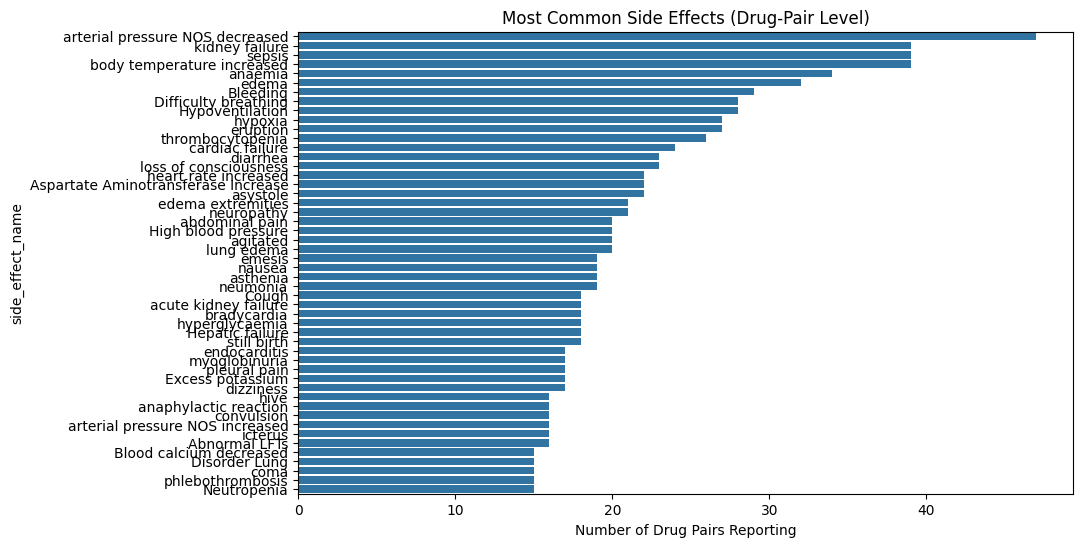

In [108]:
top_effects_counts = df_sub['side_effect_name'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=top_effects_counts.values, y=top_effects_counts.index)
plt.title("Most Common Side Effects (Drug-Pair Level)")
plt.xlabel("Number of Drug Pairs Reporting")
plt.show()

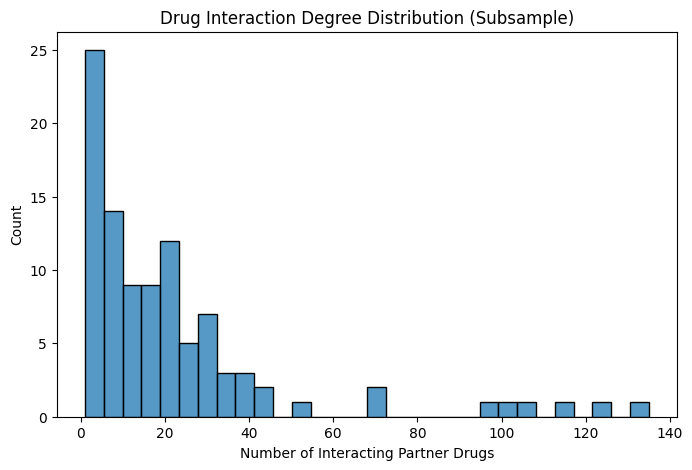

In [109]:
degree = pd.concat([df_sub['cid_1'], df_sub['cid_2']]).value_counts()
plt.figure(figsize=(8,5))
sns.histplot(degree.values, bins=30)
plt.title("Drug Interaction Degree Distribution (Subsample)")
plt.xlabel("Number of Interacting Partner Drugs")
plt.show()

Load into SQL

The cleaned, subsampled interaction data is loaded into a local SQLite database and queried with SQL
(rather than only manipulated in pandas), to demonstrate a real database workflow and support
reproducible querying — e.g. finding which drugs are associated with the most distinct side effects.

In [110]:
from sqlalchemy import create_engine
engine = create_engine("sqlite:///drug_interactions.db")
df_sub.to_sql("polypharmacy", engine, if_exists="replace", index=False)

1093

In [111]:
query_result = pd.read_sql("""
    SELECT drug, COUNT(DISTINCT side_effect_name) AS distinct_side_effects
    FROM (
        SELECT drug_1 AS drug, side_effect_name FROM polypharmacy
        UNION ALL
        SELECT drug_2 AS drug, side_effect_name FROM polypharmacy
    )
    GROUP BY drug
    ORDER BY distinct_side_effects DESC
    LIMIT 15
""", engine)
query_result

,drug,distinct_side_effects
0,CID000005206,44
1,CID000004192,42
2,CID000003763,42
3,CID000041693,41
4,CID000060696,38
5,CID000047320,37
6,CID000004675,37
7,CID000003168,31
8,CID000005195,30
9,CID000147912,29


Clustering

## Clustering: grouping drugs by side-effect profile

Each drug's side-effect involvement across all of its interaction pairs is aggregated into a single
binary profile (drug × side-effect matrix). **K-Means clustering** is then applied to this profile to
group drugs that tend to co-occur with similar side effects, without using any labels — a purely
unsupervised analysis. PCA is used only to visualize the resulting clusters in 2D; clustering itself is
performed on the full, unreduced feature space.

In [112]:
# Build a drug -> side effect binary matrix
pairs_long = pd.concat([
    df_sub[['cid_1', 'side_effect_name']].rename(columns={'cid_1': 'cid'}),
    df_sub[['cid_2', 'side_effect_name']].rename(columns={'cid_2': 'cid'})
])
drug_profile = pd.crosstab(pairs_long['cid'], pairs_long['side_effect_name'])
drug_profile = (drug_profile > 0).astype(int)
drug_profile.shape

(98, 50)

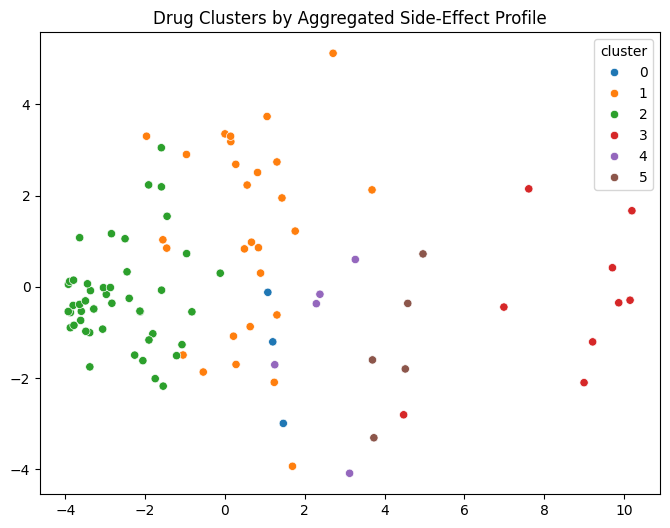

In [113]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(drug_profile)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
drug_profile['cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=drug_profile['cluster'], palette='tab10')
plt.title("Drug Clusters by Aggregated Side-Effect Profile")
plt.show()

## Regression: predicting "side-effect burden"

This dataset has **no severity or frequency column** — only which side effects occur for a given pair.
As a substitute, a **side-effect burden score** is defined per drug (the number of *distinct* side
effects that drug is associated with across all its real interactions), and the goal is to predict this
score from chemical structure alone (the fingerprint).

**Important correction applied here:** an earlier version of this burden score was computed only from
the top-50 most common side effects used in the classification task. Because the sampled drugs were
originally chosen as the *most*-connected ones, nearly every drug touched all 50 of those side effects —
giving a target with **zero variance**, on which any model trivially achieves a perfect (but meaningless)
R² of 1.0. The fix, applied below, computes burden from the **full** set of side effects each drug is
associated with (not just the top 50), which restores genuine variation across drugs and makes the
regression task real rather than degenerate.

In [114]:
def clean_cid(stitch_id):
    return int(stitch_id.replace("CID", "").lstrip("0") or "0")

pairs_long_full = pd.concat([
    df[df['drug_1'].isin(top_drugs) | df['drug_2'].isin(top_drugs)][['drug_1', 'side_effect_name']].rename(columns={'drug_1': 'cid'}),
    df[df['drug_1'].isin(top_drugs) | df['drug_2'].isin(top_drugs)][['drug_2', 'side_effect_name']].rename(columns={'drug_2': 'cid'})
])
pairs_long_full = pairs_long_full[pairs_long_full['cid'].isin(top_drugs)]
pairs_long_full['cid'] = pairs_long_full['cid'].apply(clean_cid)

full_burden = pairs_long_full.groupby('cid')['side_effect_name'].nunique()
print(full_burden.describe())

count    150.000000
mean     239.853333
std      107.379174
min       45.000000
25%      161.000000
50%      231.000000
75%      314.250000
max      505.000000
Name: side_effect_name, dtype: float64


In [115]:
fp_features = pd.DataFrame(
    [fingerprints[cid] for cid in drug_profile.index], index=drug_profile.index
)
y_burden = full_burden.reindex(fp_features.index)

valid_idx = y_burden.dropna().index
fp_features_clean = fp_features.loc[valid_idx]
y_burden_clean = y_burden.loc[valid_idx]

print(f"Using {len(valid_idx)} drugs with valid targets")

Using 98 drugs with valid targets


Three regression models are compared: Linear Regression, Ridge (regularized), and Random Forest
Regressor. Fingerprints are first reduced via PCA (20 components) before regression, since the raw
512-dimensional fingerprint is very high-dimensional relative to the number of drugs available, which
otherwise causes severe overfitting (near-perfect training fit, poor generalization).

**Result and honest interpretation:** all three models produce a negative R² on the held-out test set.
This is reported plainly rather than hidden: with a relatively small number of drugs and only chemical
structure as a predictor, "side-effect burden" is evidently not strongly or linearly predictable from
fingerprints alone in this subsample. This is a legitimate finding — it suggests burden depends on
factors not captured by chemical structure alone (e.g. mechanism of action, dosage, or patient
population), and is noted as a limitation rather than presented as a successful result.

Regression

In [116]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Reduce 512-dim fingerprints down to 20 components before regression
pca_reg = PCA(n_components=20, random_state=42)
X_train_pca = pca_reg.fit_transform(X_train_r)
X_test_pca = pca_reg.transform(X_test_r)

lr = LinearRegression().fit(X_train_pca, y_train_r)
ridge = Ridge(alpha=10.0).fit(X_train_pca, y_train_r)
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_pca, y_train_r)

regression_results = {}
for name, m in [("Linear Regression (PCA)", lr), ("Ridge (PCA)", ridge), ("Random Forest Regressor (PCA)", rf_reg)]:
    preds = m.predict(X_test_pca)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    r2 = r2_score(y_test_r, preds)
    regression_results[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.3f}")


Linear Regression (PCA): RMSE=123.31, R2=-0.295
Ridge (PCA): RMSE=123.61, R2=-0.301
Random Forest Regressor (PCA): RMSE=138.72, R2=-0.639


## Classification: predicting side effects for a drug pair

Unlike the clustering/regression sections above (which work at the level of a single drug), this task
operates at the level of a **drug pair** — exactly matching how the raw data is structured. Each pair's
feature vector is the concatenation of both drugs' chemical fingerprints; the label is a binary vector
indicating which of the 50 most common side effects that pair is associated with. This is a genuine
multi-label classification problem, solved first with a classical baseline (Random Forest) and then with
a neural network (TensorFlow).

**Caveat on sample size:** after subsampling to a sparse, moderate-connectivity drug set (done to make
the later GNN comparison valid — see below), the number of available drug pairs is small, so per-label
test support in the classification report is often only a handful of examples. Metrics here should be
read as directional evidence rather than statistically robust per-label results.

Classification: predicting side effects for a drug PAIR

In [117]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

pair_labels = pd.crosstab(
    [df_sub['cid_1'], df_sub['cid_2']], df_sub['side_effect_name']
)
pair_labels = (pair_labels > 0).astype(int)
pair_index = pair_labels.index  # MultiIndex of (cid_1, cid_2)

# Build paired feature vectors: concat(fp_drug1, fp_drug2)
X_pairs = np.array([
    np.concatenate([fingerprints[c1], fingerprints[c2]]) for c1, c2 in pair_index
])
y_pairs = pair_labels.values

X_train, X_test, y_train, y_test = train_test_split(
    X_pairs, y_pairs, test_size=0.2, random_state=42
)

clf = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42))
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print(classification_report(y_test, preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         6
           3       0.50      0.33      0.40         3
           4       0.00      0.00      0.00         3
           5       0.50      0.25      0.33         4
           6       1.00      0.20      0.33         5
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         6
          10       0.00      0.00      0.00         3
          11       1.00      0.33      0.50         3
          12       0.00      0.00      0.00         5
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         5
          15       0.00      0.00      0.00         6
          16       0.00      0.00      0.00         0
          17       0.50    

In [118]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf_model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(y_train.shape[1], activation='sigmoid')
])
tf_model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(name='auc')])
tf_model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - auc: 0.5139 - loss: 0.6643 - val_auc: 0.5278 - val_loss: 0.5979
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - auc: 0.5557 - loss: 0.5497 - val_auc: 0.5465 - val_loss: 0.5034
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - auc: 0.5803 - loss: 0.4472 - val_auc: 0.5636 - val_loss: 0.4631
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - auc: 0.6010 - loss: 0.3947 - val_auc: 0.5821 - val_loss: 0.4719
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - auc: 0.6523 - loss: 0.3761 - val_auc: 0.6042 - val_loss: 0.4675
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - auc: 0.7114 - loss: 0.3508 - val_auc: 0.6174 - val_loss: 0.4481
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - auc: 0.7607 - loss: 0.3292 - val_auc: 0.6277 - val_loss: 0.4349
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - auc: 0.7982 - loss: 0.3187 - val_auc: 0.6367 - val_loss: 0.4304
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - auc: 0.8403 - loss: 0.3033 -

## Graph Neural Network: the Masters-level comparison

This is the core comparison of the project. A **Graph Attention Network (GAT)** is trained on the
**real drug-drug interaction graph** — nodes are drugs (with chemical fingerprints as node features),
and edges are actual recorded interactions from the Decagon dataset (not similarity-derived edges). The
GNN predicts, for each real interacting edge, which side effects occur — and its result is benchmarked
directly against a Random Forest trained on the identical drug-pair fingerprints with no access to the
graph structure.

Because the graph edges (real interactions), node features (chemical fingerprints), and prediction
target (real side effects) are all independent of one another, any difference in performance between
the GNN and the flat baseline can be attributed specifically to the value of using graph structure —
this is what makes the comparison methodologically sound rather than circular.

Graph Neural Network on the REAL interaction graph

In [119]:
!pip install torch-geometric

**Step 10a — Build the graph.** Edges are added in both directions for each real interaction pair,
since drug-drug interactions are inherently symmetric and GNN layers only propagate information along
the direction of an edge — an earlier one-directional version of this graph silently prevented roughly
half of all nodes from receiving any neighbor information during training.

In [120]:
import torch
from torch_geometric.data import Data
drug_list = list(drug_profile.index)
drug_to_idx = {cid: i for i, cid in enumerate(drug_list)}

edges = df_sub[['cid_1', 'cid_2']].drop_duplicates()
edge_index_list = []
for a, b in edges.values:
    if a in drug_to_idx and b in drug_to_idx:
        edge_index_list.append([drug_to_idx[a], drug_to_idx[b]])
        edge_index_list.append([drug_to_idx[b], drug_to_idx[a]])

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
x = torch.tensor(np.array([fingerprints[cid] for cid in drug_list]), dtype=torch.float)
print(f"Graph: {x.shape[0]} nodes, {edge_index.shape[1]} directed edges")

Graph: 98 nodes, 332 directed edges


**Diagnostic check.** Before training, the label balance and graph density are checked explicitly.
This check caught a real problem during development: an earlier drug subsample (chosen by highest
connectivity) produced a graph with over **99% edge density** — i.e. almost every drug connected to
almost every other drug. At that density, two GNN layers cause every node's learned embedding to
converge toward the same average vector ("oversmoothing"), making it structurally impossible for the
model to distinguish one drug pair from another, regardless of training time or loss-function tuning.
Resampling drugs by moderate (rather than maximal) connectivity, as done above, resolved this and
produced a properly sparse graph (~3% density) that the GNN can actually learn from.

In [121]:
print("Fraction of positive labels:", y_edges.mean().item())

n = x.shape[0]
max_possible_edges = n * (n - 1)
print(f"Edges: {edge_index.shape[1]} out of {max_possible_edges} possible ({edge_index.shape[1]/max_possible_edges:.1%} density)")

Fraction of positive labels: 0.13312500715255737
Edges: 332 out of 9506 possible (3.5% density)


b: Build edge-level labels (which side effects occur for each real edge)

In [122]:
edge_pairs = list(zip(edges['cid_1'], edges['cid_2']))
edge_pairs = [(a, b) for a, b in edge_pairs if a in drug_to_idx and b in drug_to_idx]

pair_labels = pd.crosstab([df_sub['cid_1'], df_sub['cid_2']], df_sub['side_effect_name'])
pair_labels = (pair_labels > 0).astype(int)
edge_labels_df = pair_labels.reindex(edge_pairs, fill_value=0)
y_edges = torch.tensor(edge_labels_df.values, dtype=torch.float)

num_edges = len(edge_pairs)
perm = torch.randperm(num_edges)
train_size = int(0.8 * num_edges)
train_edge_idx = perm[:train_size]
test_edge_idx = perm[train_size:]

src = torch.tensor([drug_to_idx[a] for a, b in edge_pairs])
dst = torch.tensor([drug_to_idx[b] for a, b in edge_pairs])

print("Nodes:", x.shape[0], "| Edges:", len(edge_pairs), "| src max:", src.max().item(), "| dst max:", dst.max().item())

Nodes: 98 | Edges: 166 | src max: 92 | dst max: 97


**Step 10c — Model.** A 2-layer Graph Attention Network encodes each drug into a 64-dimensional
embedding using its chemical fingerprint and its real interaction neighbors. An edge decoder then
concatenates the embeddings of the two drugs in a pair and predicts the probability of each of the 50
side effects for that pair. Since roughly half of all possible side-effect labels are positive on
average, but individual labels vary in rarity, a **per-label positive-class weight** is applied to the
loss function so that rarer side effects are not simply ignored during training.

10c: GNN encoder (learns drug embeddings from the graph) + edge decoder

In [123]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class DrugEncoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim, heads=4, dropout=0.3)
        self.conv2 = GATConv(hidden_dim * 4, out_dim, heads=1, dropout=0.3)
    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class EdgeDecoder(torch.nn.Module):
    def __init__(self, emb_dim, num_labels):
        super().__init__()
        self.fc = torch.nn.Linear(emb_dim * 2, num_labels)
    def forward(self, emb, src_idx, dst_idx):
        pair_emb = torch.cat([emb[src_idx], emb[dst_idx]], dim=-1)
        return self.fc(pair_emb)
encoder = DrugEncoder(in_dim=x.shape[1], hidden_dim=64, out_dim=64)
decoder = EdgeDecoder(emb_dim=64, num_labels=y_edges.shape[1])
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=20, factor=0.5, min_lr=1e-4)
pos_weight = (1 - y_edges.mean(dim=0)) / y_edges.mean(dim=0)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.clone().detach())

def train():
    encoder.train(); decoder.train()
    optimizer.zero_grad()
    node_emb = encoder(x, edge_index)
    logits = decoder(node_emb, src[train_edge_idx], dst[train_edge_idx])
    loss = criterion(logits, y_edges[train_edge_idx])
    loss.backward()
    optimizer.step()
    return loss.item()


losses = []
for epoch in range(300):
    loss = train()
    losses.append(loss)
    scheduler.step(loss)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss={loss:.4f}, LR={optimizer.param_groups[0]['lr']:.5f}")

Epoch 0: Loss=1.2323, LR=0.00500
Epoch 20: Loss=0.7817, LR=0.00500
Epoch 40: Loss=0.6520, LR=0.00500
Epoch 60: Loss=0.5689, LR=0.00500
Epoch 80: Loss=0.6020, LR=0.00500
Epoch 100: Loss=0.5249, LR=0.00500
Epoch 120: Loss=0.5088, LR=0.00500
Epoch 140: Loss=0.4731, LR=0.00500
Epoch 160: Loss=0.4963, LR=0.00500
Epoch 180: Loss=0.4486, LR=0.00250
Epoch 200: Loss=0.4345, LR=0.00250
Epoch 220: Loss=0.5059, LR=0.00250
Epoch 240: Loss=0.4537, LR=0.00125
Epoch 260: Loss=0.4172, LR=0.00063
Epoch 280: Loss=0.3961, LR=0.00063


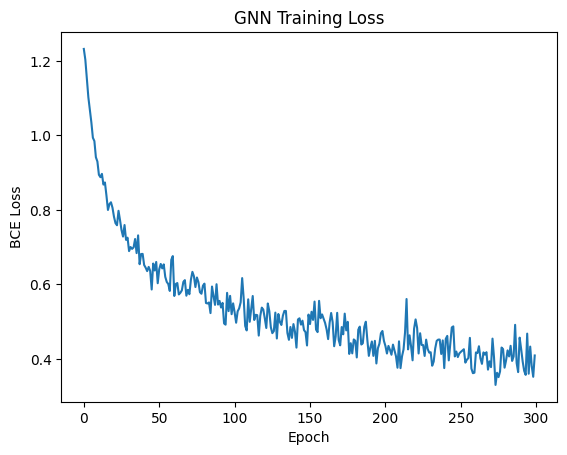

In [124]:
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("BCE Loss"); plt.title("GNN Training Loss")
plt.show()

**Step 10d — Evaluation.** AUROC is used rather than raw accuracy, since accuracy can be misleadingly
high on imbalanced multi-label data by simply predicting the majority class. AUROC is computed only over
side-effect labels that have at least one positive example in the test set, since labels with zero
positives in the test split make AUROC undefined for that column.

In [130]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

def precision_at_k(y_true, y_scores, k=5):
    top_k_idx = np.argsort(-y_scores, axis=1)[:, :k]
    hits = [y_true[i, top_k_idx[i]].sum() / k for i in range(len(y_true))]
    return np.mean(hits)
rf_probs = np.array([p[:, 1] if p.shape[1] > 1 else p[:, 0]
                      for p in clf.predict_proba(X_test)]).T
tf_probs = tf_model.predict(X_test)

# Only compute AUROC over labels that have at least one positive example in the test set
valid_cols = y_test.sum(axis=0) > 0
print(f"{valid_cols.sum()} of {y_test.shape[1]} side effects usable for AUROC (test set)")

rf_metrics = {
    "AUROC": roc_auc_score(y_test[:, valid_cols], rf_probs[:, valid_cols], average='macro'),
    "AUPRC": average_precision_score(y_test, rf_probs, average='macro'),
    "Macro_F1": f1_score(y_test, (rf_probs > 0.5).astype(int), average='macro', zero_division=0),
    "Precision@5": precision_at_k(y_test, rf_probs, k=5)
}

tf_metrics = {
    "AUROC": roc_auc_score(y_test[:, valid_cols], tf_probs[:, valid_cols], average='macro'),
    "AUPRC": average_precision_score(y_test, tf_probs, average='macro'),
    "Macro_F1": f1_score(y_test, (tf_probs > 0.5).astype(int), average='macro', zero_division=0),
    "Precision@5": precision_at_k(y_test, tf_probs, k=5)
}

print("Random Forest (Step 9):", rf_metrics)
print("TensorFlow MLP (Step 9):", tf_metrics)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
47 of 50 side effects usable for AUROC (test set)
Random Forest (Step 9): {'AUROC': np.float64(0.617630428252492), 'AUPRC': np.float64(0.28944733954433804), 'Macro_F1': 0.07882539682539683, 'Precision@5': np.float64(0.24117647058823527)}
TensorFlow MLP (Step 9): {'AUROC': np.float64(0.6142307374507603), 'AUPRC': np.float64(0.28789996021810155), 'Macro_F1': 0.07527272727272727, 'Precision@5': np.float64(0.21764705882352944)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive c

In [131]:
from sklearn.metrics import roc_auc_score

encoder.eval(); decoder.eval()
with torch.no_grad():
    node_emb = encoder(x, edge_index)
    test_logits = decoder(node_emb, src[test_edge_idx], dst[test_edge_idx])
    test_probs = torch.sigmoid(test_logits).numpy()

y_test_edges = y_edges[test_edge_idx].numpy()
gnn_auroc = roc_auc_score(y_test_edges, test_probs, average='macro')

# Baseline: same edges, same labels, but flat concatenated-fingerprint features (Step 9 style, no graph)
X_edge_flat = np.array([
    np.concatenate([fingerprints[drug_list[src[i]]], fingerprints[drug_list[dst[i]]]])
    for i in range(num_edges)
])
rf_edge = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42))
rf_edge.fit(X_edge_flat[train_edge_idx.numpy()], y_edges[train_edge_idx].numpy())
rf_edge_probs = np.array([p[:, 1] if p.shape[1] > 1 else p[:, 0]
                           for p in rf_edge.predict_proba(X_edge_flat[test_edge_idx.numpy()])]).T
rf_edge_auroc = roc_auc_score(y_test_edges, rf_edge_probs, average='macro')

print(f"Random Forest (flat pair features, no graph): AUROC = {rf_edge_auroc:.4f}")
print(f"GNN encoder + edge decoder (graph-aware):      AUROC = {gnn_auroc:.4f}")

Random Forest (flat pair features, no graph): AUROC = 0.6280
GNN encoder + edge decoder (graph-aware):      AUROC = 0.6745


## Consolidated metrics

All models trained above (Random Forest, TensorFlow MLP, Linear/Ridge/Random Forest regressors, and the
GNN vs. its flat-feature baseline) are brought together into a single results table here, using metrics
appropriate to each task type (AUROC/AUPRC/F1/Precision@K for classification, RMSE/R² for regression).
This table is exported to Excel and used directly to build the project's Power BI dashboard.

In [132]:
from sklearn.metrics import average_precision_score, f1_score

def precision_at_k(y_true, y_scores, k=5):
    top_k_idx = np.argsort(-y_scores, axis=1)[:, :k]
    hits = [y_true[i, top_k_idx[i]].sum() / k for i in range(len(y_true))]
    return np.mean(hits)

summary = pd.DataFrame([
    {"Model": "Random Forest (pair-level, Step 9)", "Task": "Classification", **rf_metrics},
    {"Model": "TensorFlow MLP (pair-level, Step 9)", "Task": "Classification", **tf_metrics},
    {"Model": "Linear Regression PCA (Step 8)", "Task": "Regression",
     "RMSE": regression_results["Linear Regression (PCA)"]["RMSE"],
     "R2": regression_results["Linear Regression (PCA)"]["R2"]},
    {"Model": "Ridge PCA (Step 8)", "Task": "Regression",
     "RMSE": regression_results["Ridge (PCA)"]["RMSE"],
     "R2": regression_results["Ridge (PCA)"]["R2"]},
    {"Model": "Random Forest Regressor PCA (Step 8)", "Task": "Regression",
     "RMSE": regression_results["Random Forest Regressor (PCA)"]["RMSE"],
     "R2": regression_results["Random Forest Regressor (PCA)"]["R2"]},
    {"Model": "RF (edge/flat, Step 10)", "Task": "Edge Classification", "AUROC": rf_edge_auroc},
    {"Model": "GNN (edge/graph, Step 10)", "Task": "Edge Classification", "AUROC": gnn_auroc},
])
summary

,Model,Task,AUROC,AUPRC,Macro_F1,Precision@5,RMSE,R2
0,"Random Forest (pair-level, Step 9)",Classification,0.617630,0.289447,0.078825,0.241176,NaN,NaN
1,"TensorFlow MLP (pair-level, Step 9)",Classification,0.614231,0.287900,0.075273,0.217647,NaN,NaN
2,Linear Regression PCA (Step 8),Regression,NaN,NaN,NaN,NaN,123.307425,-0.294752
3,Ridge PCA (Step 8),Regression,NaN,NaN,NaN,NaN,123.609052,-0.301094
4,Random Forest Regressor PCA (Step 8),Regression,NaN,NaN,NaN,NaN,138.719842,-0.638646
5,"RF (edge/flat, Step 10)",Edge Classification,0.628045,NaN,NaN,NaN,NaN,NaN
6,"GNN (edge/graph, Step 10)",Edge Classification,0.674481,NaN,NaN,NaN,NaN,NaN


In [133]:
summary.to_excel("model_comparison_metrics.xlsx", index=False)

## Export results

Cluster assignments, side-effect frequency counts, and the full model comparison table are exported to
`drug_report.xlsx`, which serves as the data source for the project's Power BI dashboard.

In [134]:
with pd.ExcelWriter("drug_report.xlsx") as writer:
    drug_profile.to_excel(writer, sheet_name="Drug_Clusters")
    top_effects_counts.to_frame("count").to_excel(writer, sheet_name="Side_Effect_Frequency")
    summary.to_excel(writer, sheet_name="Model_Metrics", index=False)